# Monthly forecasting of equivalent new maternity leaves in a hospital

## Notebook 02 — Modeling

This notebook builds and compares **multiple linear regression** models to predict the variable:

```text
mat_eq_nuevas_mes
```

The objective is to test different combinations of candidate variables and select the model that offers the best balance between:

- out-of-sample error,
- parsimony,
- low collinearity,
- interpretability,
- operational usefulness.

Two approaches are compared:

1. `LinearRegression` from `scikit-learn`.
2. `OLS` from `statsmodels`.

## Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from itertools import combinations

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

import joblib

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

sns.set_style('whitegrid')

## Loading the dataset prepared in Notebook 1

In [2]:
df = pd.read_csv('../data/df_model_full.csv')

df.head()

,MES,mat_eq_nuevas_mes,ppef_mujeres_25_40,pct_indef_25_40,pct_amb_fill_25_40,RE_ponderado_lag1,RE_ponderado_lag2,RE_ponderado_lag3,mat_eq_lag1,mat_eq_lag12,mes
0,2016-01-31,3.5400,969.6898,0.1601,0.1505,0.0000,0.0000,0.0000,0.0000,0.0000,1
1,2016-02-29,6.0628,"1,019.6952",0.1480,0.1099,15.6240,0.0000,0.0000,3.5400,0.0000,2
2,2016-03-31,5.5194,"1,033.5400",0.1455,0.1173,16.7160,15.6240,0.0000,6.0628,0.0000,3
3,2016-04-30,2.7350,"1,036.7885",0.1419,0.1133,16.4640,16.7160,15.6240,5.5194,0.0000,4
4,2016-05-31,7.0039,"1,022.9498",0.1401,0.1218,11.2560,16.4640,16.7160,2.7350,0.0000,5


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   MES                 123 non-null    object 
 1   mat_eq_nuevas_mes   123 non-null    float64
 2   ppef_mujeres_25_40  123 non-null    float64
 3   pct_indef_25_40     123 non-null    float64
 4   pct_amb_fill_25_40  123 non-null    float64
 5   RE_ponderado_lag1   123 non-null    float64
 6   RE_ponderado_lag2   123 non-null    float64
 7   RE_ponderado_lag3   123 non-null    float64
 8   mat_eq_lag1         123 non-null    float64
 9   mat_eq_lag12        123 non-null    float64
 10  mes                 123 non-null    int64  
dtypes: float64(9), int64(1), object(1)
memory usage: 10.7+ KB


## Time preparation

We convert `MES` to a date, sort the dataframe, and verify the available time range.

In [4]:
df['MES'] = pd.to_datetime(df['MES'])

df = df.sort_values('MES').reset_index(drop=True)

print('Minimum date:', df['MES'].min())
print('Maximum date:', df['MES'].max())
print('Number of observations:', len(df))

Minimum date: 2016-01-31 00:00:00
Maximum date: 2026-03-31 00:00:00
Number of observations: 123


## Control of initial rows without enough historical information

Since some variables have lags (`lag1`, `lag2`, `lag3`), the first rows may contain artificial zeros that are not real data.

In [5]:

max_lag = 12

df_modeling = df.iloc[max_lag:].copy()

print("Original rows:", len(df))
print("Rows available for modeling:", len(df_modeling))
print("First date used for modeling:", df_modeling["MES"].min())

Original rows: 123
Rows available for modeling: 111
First date used for modeling: 2017-01-31 00:00:00


## Definition of the target variable and candidate variables

The target variable is:

```text
mat_eq_nuevas_mes
```

The candidate variables come from the exploratory analysis in Notebook 1. They include structural, labor, family, pregnancy-risk, target-lag, and monthly seasonality variables.

In [6]:
target = 'mat_eq_nuevas_mes'

candidate_features = [
    'ppef_mujeres_25_40',
    'pct_indef_25_40',
    'pct_amb_fill_25_40',
    'RE_ponderado_lag1',
    'RE_ponderado_lag2',
    'RE_ponderado_lag3',
    'mat_eq_lag1',
    'mes'
]

# Quick check
missing_features = [col for col in candidate_features + [target] if col not in df.columns]

if missing_features:
    print('Columns not found:', missing_features)
else:
    print('All required variables are available.')

All required variables are available.


## Temporal train/test split

Since we are working with a monthly time series, the split should not be random.

The last time block is reserved as the test set to simulate a realistic situation: training with the past and predicting future months.

By default, the last 12 months are reserved.

In [7]:
test_size = 12

train = df_modeling.iloc[:-test_size].copy()
test = df_modeling.iloc[-test_size:].copy()

print('Train:', train['MES'].min(), '->', train['MES'].max(), '| rows:', len(train))
print('Test :', test['MES'].min(), '->', test['MES'].max(), '| rows:', len(test))

Train: 2017-01-31 00:00:00 -> 2025-03-31 00:00:00 | rows: 99
Test : 2025-04-30 00:00:00 -> 2026-03-31 00:00:00 | rows: 12


## Auxiliary evaluation functions

Several metrics are calculated:

- **MAE:** mean absolute error.
- **RMSE:** root mean squared error.
- **R²:** proportion of variance explained.
- **sMAPE:** symmetric percentage error, more stable than MAPE when values are small.

In this project, the main criterion will be **MAE**, because it is in the same units as the target variable and is easy to interpret operationally.

In [8]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator != 0

    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]) * 100


def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
        'sMAPE': smape(y_true, y_pred)
    }

## Controlled generation of variable combinations

Combinations of 2 to 5 variables are tested.

Not all possible models are tested without control, because that could encourage overfitting. In addition, rules are applied to avoid conceptually redundant combinations.

Rules applied:

1. Do not include more than one `RE_ponderado` lag in the same model.
2. Limit the maximum model size to 5 variables.

In [9]:
def is_valid_combination(features):
    re_lags = [
        'RE_ponderado_lag1',
        'RE_ponderado_lag2',
        'RE_ponderado_lag3'
    ]

    # Avoid several lags of the same pregnancy-risk indicator
    n_re_lags = sum(feature in features for feature in re_lags)
    if n_re_lags > 1:
        return False

    # Avoid two target-variable lags simultaneously
    if 'mat_eq_lag1' in features and 'mat_eq_lag12' in features:
        return False

    return True


min_features = 2
max_features = 5

feature_combinations = []

for n_features in range(min_features, max_features + 1):
    for combo in combinations(candidate_features, n_features):
        combo = list(combo)
        if is_valid_combination(combo):
            feature_combinations.append(combo)

print('Number of valid combinations:', len(feature_combinations))

pd.DataFrame({
    'n_features': [len(combo) for combo in feature_combinations],
    'features': [' + '.join(combo) for combo in feature_combinations]
}).head(20)

Number of valid combinations: 116


,n_features,features
0,2,ppef_mujeres_25_40 + pct_indef_25_40
1,2,ppef_mujeres_25_40 + pct_amb_fill_25_40
2,2,ppef_mujeres_25_40 + RE_ponderado_lag1
3,2,ppef_mujeres_25_40 + RE_ponderado_lag2
4,2,ppef_mujeres_25_40 + RE_ponderado_lag3
5,2,ppef_mujeres_25_40 + mat_eq_lag1
6,2,ppef_mujeres_25_40 + mes
7,2,pct_indef_25_40 + pct_amb_fill_25_40
8,2,pct_indef_25_40 + RE_ponderado_lag1
9,2,pct_indef_25_40 + RE_ponderado_lag2


## Grid search with `scikit-learn LinearRegression`

A `LinearRegression` model is trained for each valid combination of variables.

Although linear regression does not require scaling for prediction, a pipeline with `StandardScaler` is used to facilitate comparisons and keep a reusable structure.

In [10]:
sklearn_results = []

for features in feature_combinations:

    X_train = train[features]
    y_train = train[target]

    X_test = test[features]
    y_test = test[target]

    model = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('regressor', LinearRegression())
    ])

    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    train_metrics = regression_metrics(y_train, y_pred_train)
    test_metrics = regression_metrics(y_test, y_pred_test)

    sklearn_results.append({
        'model_type': 'sklearn_linear_regression',
        'features': features,
        'features_text': ' + '.join(features),
        'n_features': len(features),
        'MAE_train': train_metrics['MAE'],
        'RMSE_train': train_metrics['RMSE'],
        'R2_train': train_metrics['R2'],
        'MAE_test': test_metrics['MAE'],
        'RMSE_test': test_metrics['RMSE'],
        'R2_test': test_metrics['R2'],
        'sMAPE_test': test_metrics['sMAPE']
    })

sklearn_results_df = pd.DataFrame(sklearn_results)

sklearn_results_df.sort_values('MAE_test').head(10)

,model_type,features,features_text,n_features,MAE_train,RMSE_train,R2_train,MAE_test,RMSE_test,R2_test,sMAPE_test
37,sklearn_linear_regression,"[ppef_mujeres_25_40, RE_ponderado_lag1, mes]",ppef_mujeres_25_40 + RE_ponderado_lag1 + mes,3,1.9522,2.5484,0.1633,1.4976,2.0190,0.1120,21.5945
84,sklearn_linear_regression,"[ppef_mujeres_25_40, RE_ponderado_lag1, mat_eq...",ppef_mujeres_25_40 + RE_ponderado_lag1 + mat_e...,4,1.9484,2.5477,0.1638,1.5188,2.0635,0.0724,21.8758
2,sklearn_linear_regression,"[ppef_mujeres_25_40, RE_ponderado_lag1]",ppef_mujeres_25_40 + RE_ponderado_lag1,2,1.9602,2.5534,0.1600,1.5390,1.9803,0.1457,22.2050
36,sklearn_linear_regression,"[ppef_mujeres_25_40, RE_ponderado_lag1, mat_eq...",ppef_mujeres_25_40 + RE_ponderado_lag1 + mat_e...,3,1.9570,2.5527,0.1605,1.5579,2.0243,0.1073,22.4511
78,sklearn_linear_regression,"[ppef_mujeres_25_40, pct_amb_fill_25_40, RE_po...",ppef_mujeres_25_40 + pct_amb_fill_25_40 + RE_p...,4,1.9523,2.5334,0.1732,1.5614,2.0886,0.0497,22.4983
110,sklearn_linear_regression,"[ppef_mujeres_25_40, pct_amb_fill_25_40, RE_po...",ppef_mujeres_25_40 + pct_amb_fill_25_40 + RE_p...,5,1.9466,2.5319,0.1741,1.5908,2.1522,-0.0091,22.8777
31,sklearn_linear_regression,"[ppef_mujeres_25_40, pct_amb_fill_25_40, RE_po...",ppef_mujeres_25_40 + pct_amb_fill_25_40 + RE_p...,3,1.9509,2.5349,0.1722,1.5930,2.0737,0.0632,22.9729
3,sklearn_linear_regression,"[ppef_mujeres_25_40, RE_ponderado_lag2]",ppef_mujeres_25_40 + RE_ponderado_lag2,2,1.9573,2.5201,0.1818,1.6162,2.0742,0.0628,23.3049
77,sklearn_linear_regression,"[ppef_mujeres_25_40, pct_amb_fill_25_40, RE_po...",ppef_mujeres_25_40 + pct_amb_fill_25_40 + RE_p...,4,1.9463,2.5334,0.1732,1.6223,2.1382,0.0040,23.3446
39,sklearn_linear_regression,"[ppef_mujeres_25_40, RE_ponderado_lag2, mes]",ppef_mujeres_25_40 + RE_ponderado_lag2 + mes,3,1.9435,2.5127,0.1866,1.6230,2.1403,0.0021,23.3292


## Grid search with `statsmodels OLS`

The same process is repeated with `statsmodels OLS`.

This approach is useful because it allows analyzing:

- coefficients,
- statistical significance,
- AIC,
- BIC,
- adjusted training R².

In this notebook it is mainly used to compare out-of-sample performance and retain interpretability information.

In [11]:
ols_results = []

for features in feature_combinations:

    X_train = train[features]
    y_train = train[target]

    X_test = test[features]
    y_test = test[target]

    X_train_const = sm.add_constant(X_train, has_constant='add')
    X_test_const = sm.add_constant(X_test, has_constant='add')

    model = sm.OLS(y_train, X_train_const).fit()

    y_pred_train = model.predict(X_train_const)
    y_pred_test = model.predict(X_test_const)

    train_metrics = regression_metrics(y_train, y_pred_train)
    test_metrics = regression_metrics(y_test, y_pred_test)

    ols_results.append({
        'model_type': 'statsmodels_ols',
        'features': features,
        'features_text': ' + '.join(features),
        'n_features': len(features),
        'MAE_train': train_metrics['MAE'],
        'RMSE_train': train_metrics['RMSE'],
        'R2_train': train_metrics['R2'],
        'MAE_test': test_metrics['MAE'],
        'RMSE_test': test_metrics['RMSE'],
        'R2_test': test_metrics['R2'],
        'sMAPE_test': test_metrics['sMAPE'],
        'AIC_train': model.aic,
        'BIC_train': model.bic,
        'adj_R2_train': model.rsquared_adj
    })

ols_results_df = pd.DataFrame(ols_results)

ols_results_df.sort_values('MAE_test').head(10)

,model_type,features,features_text,n_features,MAE_train,RMSE_train,R2_train,MAE_test,RMSE_test,R2_test,sMAPE_test,AIC_train,BIC_train,adj_R2_train
37,statsmodels_ols,"[ppef_mujeres_25_40, RE_ponderado_lag1, mes]",ppef_mujeres_25_40 + RE_ponderado_lag1 + mes,3,1.9522,2.5484,0.1633,1.4976,2.0190,0.1120,21.5945,474.1732,484.5537,0.1369
84,statsmodels_ols,"[ppef_mujeres_25_40, RE_ponderado_lag1, mat_eq...",ppef_mujeres_25_40 + RE_ponderado_lag1 + mat_e...,4,1.9484,2.5477,0.1638,1.5188,2.0635,0.0724,21.8758,476.1202,489.0958,0.1282
2,statsmodels_ols,"[ppef_mujeres_25_40, RE_ponderado_lag1]",ppef_mujeres_25_40 + RE_ponderado_lag1,2,1.9602,2.5534,0.1600,1.5390,1.9803,0.1457,22.2050,472.5619,480.3473,0.1425
36,statsmodels_ols,"[ppef_mujeres_25_40, RE_ponderado_lag1, mat_eq...",ppef_mujeres_25_40 + RE_ponderado_lag1 + mat_e...,3,1.9570,2.5527,0.1605,1.5579,2.0243,0.1073,22.4511,474.5062,484.8867,0.1340
78,statsmodels_ols,"[ppef_mujeres_25_40, pct_amb_fill_25_40, RE_po...",ppef_mujeres_25_40 + pct_amb_fill_25_40 + RE_p...,4,1.9523,2.5334,0.1732,1.5614,2.0886,0.0497,22.4983,475.0032,487.9788,0.1380
110,statsmodels_ols,"[ppef_mujeres_25_40, pct_amb_fill_25_40, RE_po...",ppef_mujeres_25_40 + pct_amb_fill_25_40 + RE_p...,5,1.9466,2.5319,0.1741,1.5908,2.1522,-0.0091,22.8777,476.8885,492.4593,0.1297
31,statsmodels_ols,"[ppef_mujeres_25_40, pct_amb_fill_25_40, RE_po...",ppef_mujeres_25_40 + pct_amb_fill_25_40 + RE_p...,3,1.9509,2.5349,0.1722,1.5930,2.0737,0.0632,22.9729,473.1237,483.5041,0.1460
3,statsmodels_ols,"[ppef_mujeres_25_40, RE_ponderado_lag2]",ppef_mujeres_25_40 + RE_ponderado_lag2,2,1.9573,2.5201,0.1818,1.6162,2.0742,0.0628,23.3049,469.9595,477.7449,0.1648
77,statsmodels_ols,"[ppef_mujeres_25_40, pct_amb_fill_25_40, RE_po...",ppef_mujeres_25_40 + pct_amb_fill_25_40 + RE_p...,4,1.9463,2.5334,0.1732,1.6223,2.1382,0.0040,23.3446,475.0013,487.9769,0.1380
39,statsmodels_ols,"[ppef_mujeres_25_40, RE_ponderado_lag2, mes]",ppef_mujeres_25_40 + RE_ponderado_lag2 + mes,3,1.9435,2.5127,0.1866,1.6230,2.1403,0.0021,23.3292,471.3824,481.7629,0.1609


## Joint model comparison

The results from both approaches are combined and sorted by MAE on the test set.

In [12]:
all_results = pd.concat(
    [sklearn_results_df, ols_results_df],
    ignore_index=True
)

all_results_sorted = all_results.sort_values(
    ['MAE_test', 'n_features'],
    ascending=[True, True]
).reset_index(drop=True)

all_results_sorted.head(20)[[
    'model_type',
    'n_features',
    'features_text',
    'MAE_test',
    'RMSE_test',
    'R2_test',
    'sMAPE_test'
]]

,model_type,n_features,features_text,MAE_test,RMSE_test,R2_test,sMAPE_test
0,statsmodels_ols,3,ppef_mujeres_25_40 + RE_ponderado_lag1 + mes,1.4976,2.0190,0.1120,21.5945
1,sklearn_linear_regression,3,ppef_mujeres_25_40 + RE_ponderado_lag1 + mes,1.4976,2.0190,0.1120,21.5945
2,statsmodels_ols,4,ppef_mujeres_25_40 + RE_ponderado_lag1 + mat_e...,1.5188,2.0635,0.0724,21.8758
3,sklearn_linear_regression,4,ppef_mujeres_25_40 + RE_ponderado_lag1 + mat_e...,1.5188,2.0635,0.0724,21.8758
4,statsmodels_ols,2,ppef_mujeres_25_40 + RE_ponderado_lag1,1.5390,1.9803,0.1457,22.2050
5,sklearn_linear_regression,2,ppef_mujeres_25_40 + RE_ponderado_lag1,1.5390,1.9803,0.1457,22.2050
6,sklearn_linear_regression,3,ppef_mujeres_25_40 + RE_ponderado_lag1 + mat_e...,1.5579,2.0243,0.1073,22.4511
7,statsmodels_ols,3,ppef_mujeres_25_40 + RE_ponderado_lag1 + mat_e...,1.5579,2.0243,0.1073,22.4511
8,sklearn_linear_regression,4,ppef_mujeres_25_40 + pct_amb_fill_25_40 + RE_p...,1.5614,2.0886,0.0497,22.4983
9,statsmodels_ols,4,ppef_mujeres_25_40 + pct_amb_fill_25_40 + RE_p...,1.5614,2.0886,0.0497,22.4983


## Careful selection of the best model

The model with the lowest error should not be selected automatically if it is too complex or difficult to interpret.

The best model will be selected among models with:

- good MAE on the test set,
- a moderate number of variables,
- reasonable interpretation,
- low risk of collinearity.

The following cell selects the model with the lowest MAE among models with a maximum of 4 variables. This threshold can be modified.

In [13]:
max_features_final = 4

candidate_final_models = all_results_sorted[
    all_results_sorted['n_features'] <= max_features_final
].copy()

candidate_final_models.head(10)[[
    'model_type',
    'n_features',
    'features_text',
    'MAE_test',
    'RMSE_test',
    'R2_test',
    'sMAPE_test'
]]

,model_type,n_features,features_text,MAE_test,RMSE_test,R2_test,sMAPE_test
0,statsmodels_ols,3,ppef_mujeres_25_40 + RE_ponderado_lag1 + mes,1.4976,2.0190,0.1120,21.5945
1,sklearn_linear_regression,3,ppef_mujeres_25_40 + RE_ponderado_lag1 + mes,1.4976,2.0190,0.1120,21.5945
2,statsmodels_ols,4,ppef_mujeres_25_40 + RE_ponderado_lag1 + mat_e...,1.5188,2.0635,0.0724,21.8758
3,sklearn_linear_regression,4,ppef_mujeres_25_40 + RE_ponderado_lag1 + mat_e...,1.5188,2.0635,0.0724,21.8758
4,statsmodels_ols,2,ppef_mujeres_25_40 + RE_ponderado_lag1,1.5390,1.9803,0.1457,22.2050
5,sklearn_linear_regression,2,ppef_mujeres_25_40 + RE_ponderado_lag1,1.5390,1.9803,0.1457,22.2050
6,sklearn_linear_regression,3,ppef_mujeres_25_40 + RE_ponderado_lag1 + mat_e...,1.5579,2.0243,0.1073,22.4511
7,statsmodels_ols,3,ppef_mujeres_25_40 + RE_ponderado_lag1 + mat_e...,1.5579,2.0243,0.1073,22.4511
8,sklearn_linear_regression,4,ppef_mujeres_25_40 + pct_amb_fill_25_40 + RE_p...,1.5614,2.0886,0.0497,22.4983
9,statsmodels_ols,4,ppef_mujeres_25_40 + pct_amb_fill_25_40 + RE_p...,1.5614,2.0886,0.0497,22.4983


In [14]:
best_model_row = candidate_final_models.iloc[0]

best_model_type = best_model_row['model_type']
best_features = best_model_row['features']

print('Selected best model:')
print('Type:', best_model_type)
print('Variables:', best_features)
print('Test MAE:', best_model_row['MAE_test'])
print('Test RMSE:', best_model_row['RMSE_test'])
print('Test R2:', best_model_row['R2_test'])
print('Test sMAPE:', best_model_row['sMAPE_test'])

Selected best model:
Type: statsmodels_ols
Variables: ['ppef_mujeres_25_40', 'RE_ponderado_lag1', 'mes']
Test MAE: 1.49762766875419
Test RMSE: 2.0189878632498752
Test R2: 0.1119772119824306
Test sMAPE: 21.594474504284115


## Final training of the selected best model

The identified best model is retrained to obtain predictions, residuals, and interpretable results.

In [15]:
X_train_best = train[best_features]
y_train = train[target]

X_test_best = test[best_features]
y_test = test[target]

if best_model_type == 'sklearn_linear_regression':

    best_model = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('regressor', LinearRegression())
    ])

    best_model.fit(X_train_best, y_train)

    y_pred_train_best = best_model.predict(X_train_best)
    y_pred_test_best = best_model.predict(X_test_best)

else:

    X_train_best_const = sm.add_constant(X_train_best, has_constant='add')
    X_test_best_const = sm.add_constant(X_test_best, has_constant='add')

    best_model = sm.OLS(y_train, X_train_best_const).fit()

    y_pred_train_best = best_model.predict(X_train_best_const)
    y_pred_test_best = best_model.predict(X_test_best_const)

best_metrics_test = regression_metrics(y_test, y_pred_test_best)
best_metrics_test

{'MAE': 1.49762766875419,
 'RMSE': 2.0189878632498752,
 'R2': 0.1119772119824306,
 'sMAPE': 21.594474504284115}

## Prediction vs actual value on the test set

In [16]:
test_predictions = test[['MES', target]].copy()
test_predictions['prediction'] = y_pred_test_best
test_predictions['error'] = test_predictions[target] - test_predictions['prediction']
test_predictions['abs_error'] = test_predictions['error'].abs()

test_predictions

,MES,mat_eq_nuevas_mes,prediction,error,abs_error
111,2025-04-30,3.6459,6.6926,-3.0467,3.0467
112,2025-05-31,5.9381,6.3151,-0.3770,0.3770
113,2025-06-30,10.1254,7.1878,2.9377,2.9377
114,2025-07-31,4.9743,6.5435,-1.5692,1.5692
115,2025-08-31,5.9949,6.1506,-0.1557,0.1557
116,2025-09-30,4.7787,6.5286,-1.7499,1.7499
117,2025-10-31,9.2548,6.5490,2.7058,2.7058
118,2025-11-30,6.0967,6.9369,-0.8402,0.8402
119,2025-12-31,11.0834,6.9361,4.1473,4.1473
120,2026-01-31,7.4606,7.2173,0.2433,0.2433


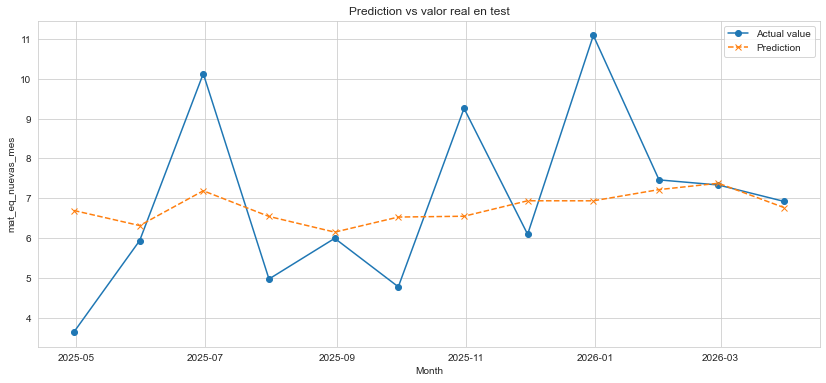

In [17]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_predictions['MES'].to_numpy(),
    test_predictions[target].to_numpy(),
    marker='o',
    label='Actual value'
)

plt.plot(
    test_predictions['MES'].to_numpy(),
    test_predictions['prediction'].to_numpy(),
    marker='x',
    linestyle='--',
    label='Prediction'
)

plt.title('Prediction vs valor real en test')
plt.xlabel('Month')
plt.ylabel(target)
plt.legend()

plt.show()

## Residual analysis on the test set

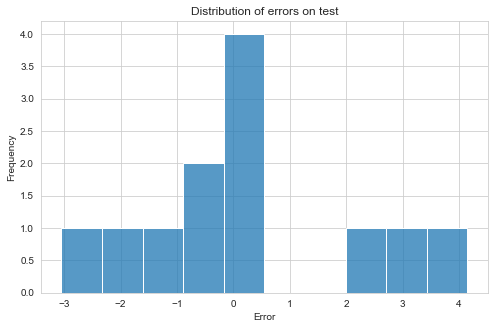

In [18]:
plt.figure(figsize=(8, 5))

sns.histplot(test_predictions['error'], bins=10)

plt.title('Distribution of errors on test')
plt.xlabel('Error')
plt.ylabel('Frequency')

plt.show()

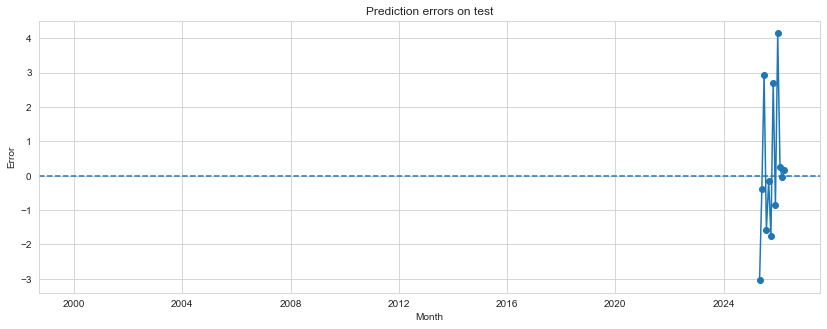

In [19]:
plt.figure(figsize=(14, 5))

plt.axhline(0, linestyle='--')

plt.plot(
    test_predictions['MES'].to_numpy(),
    test_predictions['error'].to_numpy(),
    marker='o'
)

plt.title('Prediction errors on test')
plt.xlabel('Month')
plt.ylabel('Error')

plt.show()

## Model interpretation

If the selected model is `statsmodels OLS`, the full statistical summary is displayed.

If the selected model is `scikit-learn LinearRegression`, the standardized coefficients from the pipeline are displayed, which are useful for comparing the relative importance of variables within the model.

In [20]:
if best_model_type == 'statsmodels_ols':
    display(best_model.summary())
else:
    coefficients = best_model.named_steps['regressor'].coef_

    coef_df = pd.DataFrame({
        'feature': best_features,
        'coefficient_standardized': coefficients
    }).sort_values('coefficient_standardized', ascending=False)

    display(coef_df)

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      mat_eq_nuevas_mes   R-squared:                       0.163
Model:                            OLS   Adj. R-squared:                  0.137
Method:                 Least Squares   F-statistic:                     6.182
Date:                Sun, 24 May 2026   Prob (F-statistic):           0.000697
Time:                        12:11:39   Log-Likelihood:                -233.09
No. Observations:                  99   AIC:                             474.2
Df Residuals:                      95   BIC:                             484.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -1.7009      1.667     -1.020      0.310      -5.010       1.608
ppef_mujeres_25_40     0.0041      0.001      3.730      0.000       0.002       0.006
RE_ponderado_lag1      0.1255      0.074      1.706      0.091      -0.021       0.272
mes                   -0.0467      0.076     -0.611      0.542      -0.198       0.105
==============================================================================
Omnibus:                       13.312   Durbin-Watson:                   1.866
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               14.664
Skew:                           0.793   Prob(JB):                     0.000654
Kurtosis:                       4.019   Cond. No.                     9.02e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.02e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Collinearity review of the final model

Although Notebook 1 already reviewed general collinearity, it is useful to calculate VIF only for the variables included in the selected model.

In [21]:
X_vif_best = train[best_features].copy()
X_vif_best_const = sm.add_constant(X_vif_best, has_constant='add')

vif_best_df = pd.DataFrame({
    'variable': X_vif_best_const.columns,
    'VIF': [
        variance_inflation_factor(X_vif_best_const.values, i)
        for i in range(X_vif_best_const.shape[1])
    ]
})

vif_best_df.sort_values('VIF', ascending=False)

,variable,VIF
0,const,40.6499
2,RE_ponderado_lag1,1.0487
3,mes,1.0378
1,ppef_mujeres_25_40,1.0196


## Save modeling results

The following outputs are saved:

- complete grid search results,
- predictions of the best model on the test set,
- the `scikit-learn` model if the selected best model is of that type.

If the best model is `statsmodels OLS`, a summary of results is saved and the model can be reconstructed using the selected variables.

In [22]:
# Create folders if they do not exist
import os

os.makedirs('../outputs/reports', exist_ok=True)
os.makedirs('../outputs/model', exist_ok=True)

# Save grid search results
all_results_sorted.to_csv(
    '../outputs/reports/rlm_grid_search_results.csv',
    index=False
)

# Save test predictions
test_predictions.to_csv(
    '../outputs/reports/best_rlm_test_predictions.csv',
    index=False
)

# Save best model information
best_model_info = pd.DataFrame([{
    'model_type': best_model_type,
    'features': ' + '.join(best_features),
    'MAE_test': best_metrics_test['MAE'],
    'RMSE_test': best_metrics_test['RMSE'],
    'R2_test': best_metrics_test['R2'],
    'sMAPE_test': best_metrics_test['sMAPE']
}])

best_model_info.to_csv(
    '../outputs/reports/best_rlm_model_info.csv',
    index=False
)

# Save sklearn model if applicable
if best_model_type == 'sklearn_linear_regression':
    joblib.dump(best_model, '../outputs/model/best_rlm_model.joblib')

print('Files saved successfully.')

Files saved successfully.


## Conclusions of Notebook 2

This notebook has built and compared multiple linear regression specifications based on the candidate variables generated in Notebook 1.

The main result is a table of models sorted by out-of-sample error. The final selection should not be based only on the lowest error, but on a balance between:

- predictive ability,
- number of variables,
- stability,
- absence of severe collinearity,
- substantive interpretation.

The next recommended step is to compare the best multiple linear regression model against simple baseline models in:

```text
notebooks/03_baselines_and_model_comparison.ipynb
```

This comparison will answer the key question:

> Does the multiple linear regression model add value compared with simple prediction rules?